In [1]:
from utils.dataset import GLORYSDS
from utils.config import RAW_CONFIG, DATA_DIR

In [2]:
ds_name = "cmems_mod_glo_phy_my_0.083deg_P1D-m_multi-vars_156.00W-121.42W_41.83N-63.08N_0.49m_2021-06-25-2021-06-30.nc"
ds = GLORYSDS(DATA_DIR/ds_name, days = False, grid_size = 200, normalize=True)
sample_image, sample_label = ds[99]
print(f"{sample_image.shape}, {sample_label.shape}")
print(ds.data_variables.keys())

(6, 6, 256, 416) (6, 256, 416) (6, 1, 256, 416)
(6, 256, 416) (1, 256, 416)
(106496, 6) (106496, 1)
(6, 6, 256, 416) (6, 256, 416) (6, 1, 256, 416)
(6, 256, 416) (1, 256, 416)
(106496, 6) (106496, 1)
(6, 6, 256, 416) (6, 256, 416) (6, 1, 256, 416)
(6, 256, 416) (1, 256, 416)
(106496, 6) (106496, 1)
(6, 6, 256, 416) (6, 256, 416) (6, 1, 256, 416)
(6, 256, 416) (1, 256, 416)
(106496, 6) (106496, 1)
(6, 6, 256, 416) (6, 256, 416) (6, 1, 256, 416)
(6, 256, 416) (1, 256, 416)
(106496, 6) (106496, 1)
(6, 6, 256, 416) (6, 256, 416) (6, 1, 256, 416)
(6, 256, 416) (1, 256, 416)
(106496, 6) (106496, 1)
6 6
(6, 200, 200) (1, 200, 200)
(6, 6, 200, 200) (6, 1, 200, 200)
(6, 200, 200), (1, 200, 200)
dict_keys(['bottomT', 'so', 'thetao', 'uo', 'vo', 'zos'])


In [3]:
import numpy as np

var_arrays = {}

for key, value in ds.data_variables.items():
    v_data = value.data
    v_data = v_data[0]
    v_data = np.squeeze(v_data, axis=0)
    var_arrays[key] = v_data
    print(value.data.shape)
    print(v_data.shape)

(6, 1, 256, 416)
(256, 416)
(6, 1, 256, 416)
(256, 416)
(6, 1, 256, 416)
(256, 416)
(6, 1, 256, 416)
(256, 416)
(6, 1, 256, 416)
(256, 416)
(6, 1, 256, 416)
(256, 416)


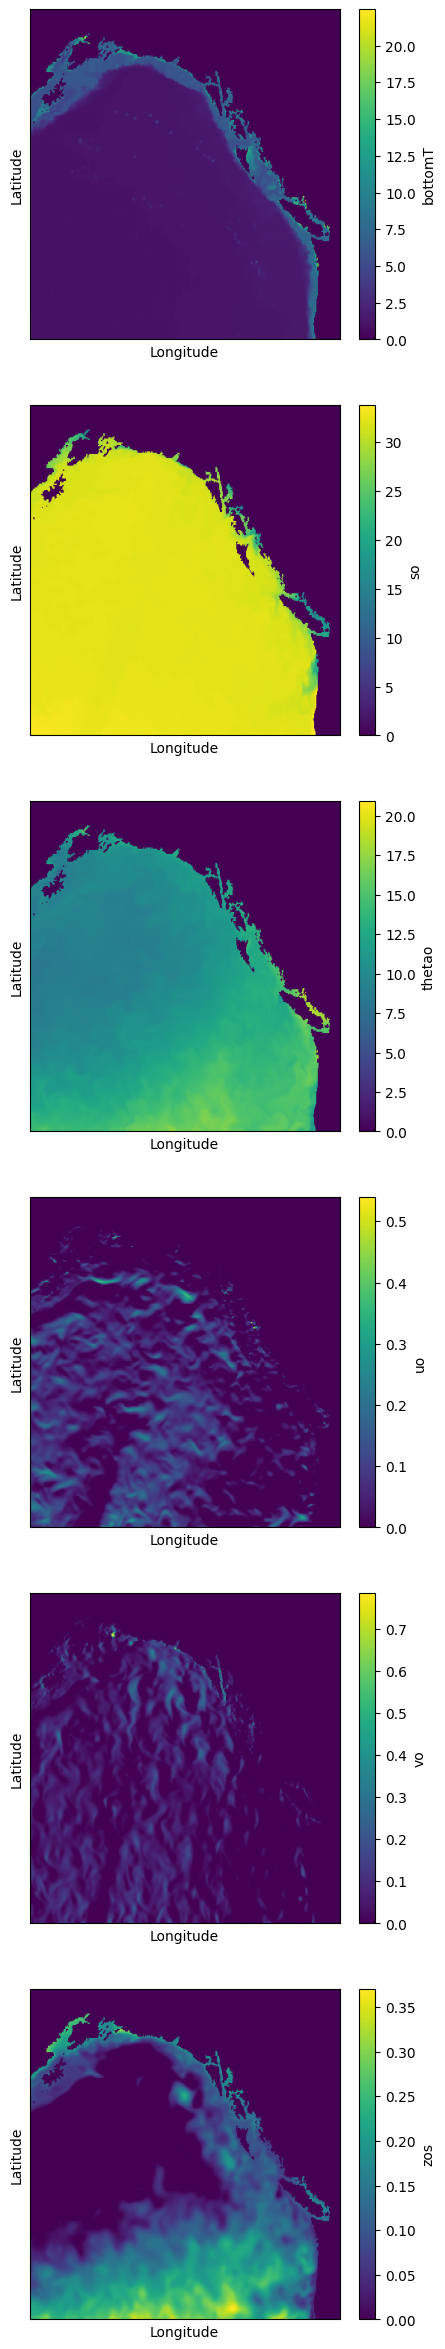

In [4]:
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np

def plot_var(axis, fig, var, var_name):
    vmin = 0
    vmax = np.max(var)
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")
    im = axis.imshow(var, origin='lower', aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    axis.set_xticks([])
    axis.set_yticks([])
    fig.colorbar(im, ax=axis, label=var_name)

def plot_day():
    fig, axs = plt.subplots(figsize=(5, 5*len(var_arrays.keys())), nrows = len(var_arrays.keys()))
    for i, (var, arr) in enumerate(var_arrays.items()):
        plot_var(axs[i], fig, arr, var)
    # plot_var(axs[1], fig, day, mlds, "Depth of Mixed Ocean Layer (m)")
    # plot_var(axs[0], fig, day, thetao, "Sea Water Pressure at Sea Floor (dbar)")

# widgets.interact(plot_day, day=slider)

plot_day()

In [5]:
sample_image.data.shape

(6, 200, 200)

(6, 200, 200)


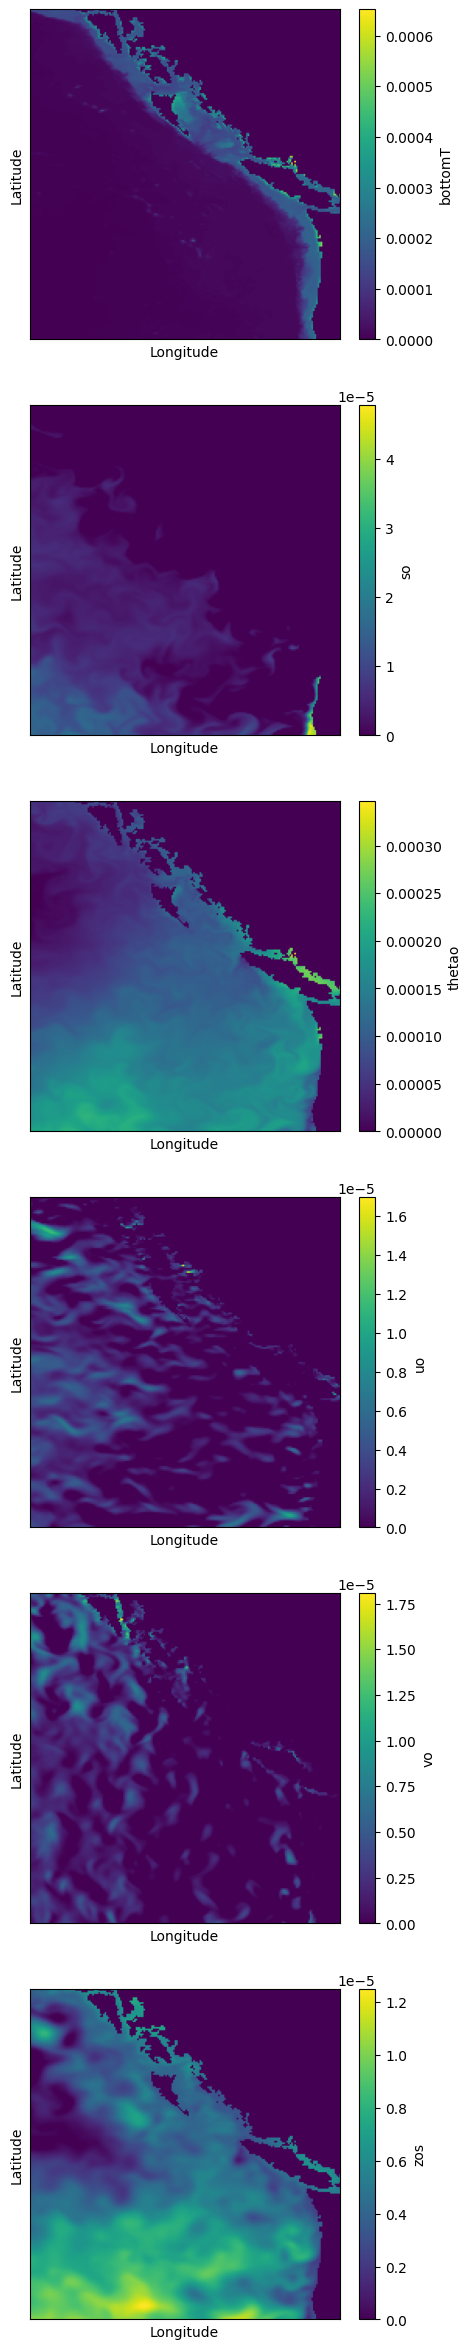

In [6]:
arrays_to_plot = []
print(sample_image.shape)
for i in range(sample_image.shape[0]):
    arrays_to_plot.append(sample_image[i])

def plot(arrays_to_plot):
    fig, axs = plt.subplots(figsize=(5, 5*len(var_arrays.keys())), nrows = len(var_arrays.keys()))
    for i, (arr, var) in enumerate(zip(arrays_to_plot, var_arrays.keys())):
        plot_var(axs[i], fig, arr, var)


plot(arrays_to_plot)